# Employee Performance and Workforce Productivity Analysis using HR Analytics Data

## Project Objective
The objective of this project is to analyze employee performance indicators such as KPI scores, attendance percentage, task completion rates, peer ratings, and manager feedback to identify workforce productivity trends and support HR decision-making.
This analysis helps understand the factors influencing employee performance and provides insights for improving workforce efficiency.

### Import Libraries
#### To load all required libraries for data analysis and visualization.
##### pandas (pd) → used to load and manipulate data (DataFrame)
##### numpy (np) → used for numerical operations
##### matplotlib.pyplot (plt) → basic plotting library
##### seaborn (sns) → advanced statistical visualizations
##### Why used:
These libraries are essential for performing EDA and creating graphs.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
### To load the dataset into Python.
##### read_csv() → reads CSV file
##### df → DataFrame (table format)
##### head() → shows first 5 rows
#### Why used:
To understand how the dataset looks initially

In [38]:
df = pd.read_csv("Employee_Performance_Dataset.csv")
df.head()

,Employee ID,Name,Department,Job Role,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours,Promotion Eligibility
0,376063,Manikya Badami,Sales,Sales Executive,61,91.03,94.40,4.5,78.19,42,3.7,18,No
1,810690,Zara Mahal,Marketing,Marketing Executive,91,83.36,78.45,4.7,71.39,46,4.5,15,Yes
2,520956,Sana Gera,Finance,Accountant,100,65.39,99.50,4.4,80.20,51,3.5,7,No
3,202996,Zoya Wadhwa,Marketing,Content Strategist,100,82.90,79.83,4.3,71.51,43,5.0,9,Yes
4,383410,Baiju Doctor,Sales,Sales Executive,80,90.90,89.92,3.7,78.03,51,3.1,29,No


# Shape of dataset
Understand dataset size

Know how much data you are working with

Useful before and after cleaning


In [39]:
# Shape of dataset
df.shape

(5000, 13)

# Dataset info
It gives a complete overview of your dataset

In [40]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee ID            5000 non-null   int64  
 1   Name                   5000 non-null   str    
 2   Department             5000 non-null   str    
 3   Job Role               5000 non-null   str    
 4   Performance Score      5000 non-null   int64  
 5   KPI Score              5000 non-null   float64
 6   Attendance (%)         5000 non-null   float64
 7   Peer Rating            5000 non-null   float64
 8   Task Completion (%)    5000 non-null   float64
 9   Work Hours Logged      5000 non-null   int64  
 10  Manager Feedback       5000 non-null   float64
 11  Training Hours         5000 non-null   int64  
 12  Promotion Eligibility  5000 non-null   str    
dtypes: float64(5), int64(4), str(4)
memory usage: 507.9 KB


# df.describe()
##### df.describe() provides a statistical summary of numerical columns.It includes mean (average), minimum and maximum values, and standard deviation, which helps in understanding the distribution and variability of the data.

mean-The average value of a column

min-The smallest value in the column

max-The largest value in the column

standard deviation-How much the data is spread out from the average


In [41]:
# Descriptive statistics
df.describe()

,Employee ID,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,554223.243400,74.779400,77.384996,87.466720,4.000080,84.978782,44.929800,4.001500,14.876800
std,261672.832133,14.666211,10.157152,7.230827,0.580889,8.696399,5.961106,0.579257,9.005523
min,100021.000000,50.000000,60.010000,75.010000,3.000000,70.010000,35.000000,3.000000,0.000000
25%,324261.250000,62.000000,68.327500,81.130000,3.500000,77.317500,40.000000,3.500000,7.000000
50%,556827.500000,75.000000,77.340000,87.415000,4.000000,85.125000,45.000000,4.000000,15.000000
75%,780774.500000,87.000000,86.050000,93.752500,4.500000,92.472500,50.000000,4.500000,23.000000
max,999957.000000,100.000000,94.990000,100.000000,5.000000,100.000000,55.000000,5.000000,30.000000


#### df.columns
Shows all column names

To understand structure and quality of data before analysis.

In [42]:
# Check column names
df.columns

Index(['Employee ID', 'Name', 'Department', 'Job Role', 'Performance Score',
       'KPI Score', 'Attendance (%)', 'Peer Rating', 'Task Completion (%)',
       'Work Hours Logged', 'Manager Feedback', 'Training Hours',
       'Promotion Eligibility'],
      dtype='str')

# Initial Observations
The dataset contains employee performance records with numerical and categorical features related to productivity, attendance, and feedback metrics.
#### Missing Values:
Identify missing values

Fill missing numeric values with mean
##### Why: Missing data can affect analysis results.

In [43]:
#Check Missing Values
df.isnull().sum()

Employee ID              0
Name                     0
Department               0
Job Role                 0
Performance Score        0
KPI Score                0
Attendance (%)           0
Peer Rating              0
Task Completion (%)      0
Work Hours Logged        0
Manager Feedback         0
Training Hours           0
Promotion Eligibility    0
dtype: int64

# Fill missing numeric values with mean
Missing values in numeric columns were handled using mean imputation. 

The missing values were replaced with the average of the respective column
 
to maintain data consistency.

In [44]:
# Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

,Employee ID,Name,Department,Job Role,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours,Promotion Eligibility
0,376063,Manikya Badami,Sales,Sales Executive,61,91.03,94.40,4.5,78.19,42,3.7,18,No
1,810690,Zara Mahal,Marketing,Marketing Executive,91,83.36,78.45,4.7,71.39,46,4.5,15,Yes
2,520956,Sana Gera,Finance,Accountant,100,65.39,99.50,4.4,80.20,51,3.5,7,No
3,202996,Zoya Wadhwa,Marketing,Content Strategist,100,82.90,79.83,4.3,71.51,43,5.0,9,Yes
4,383410,Baiju Doctor,Sales,Sales Executive,80,90.90,89.92,3.7,78.03,51,3.1,29,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,491321,Yashvi Barad,Finance,Auditor,56,82.83,79.64,4.6,84.20,45,4.1,5,No
4996,242212,Divyansh Sekhon,HR,Recruitment Specialist,99,88.37,78.85,4.4,87.31,49,4.3,9,Yes
4997,402062,Dhanuk Sankaran,IT,Data Analyst,82,90.61,96.89,3.9,76.09,50,3.5,22,No
4998,268203,Aayush Sampath,Sales,Business Development,88,66.38,83.38,3.1,88.17,36,3.6,5,No


# Remove Duplicates
Detect duplicate rows

Remove them
### Why:
Duplicate data can distort analysis.

In [45]:
#Check Duplicates
df.duplicated().sum()

np.int64(0)

In [46]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Data Types
Check correct data types (int, float, category)

In [47]:
#Data Types
df.dtypes

Employee ID                int64
Name                         str
Department                   str
Job Role                     str
Performance Score          int64
KPI Score                float64
Attendance (%)           float64
Peer Rating              float64
Task Completion (%)      float64
Work Hours Logged          int64
Manager Feedback         float64
Training Hours             int64
Promotion Eligibility        str
dtype: object

# Create Derived Column
Create performance categories
##### Converts KPI score into groups:
Low,

Average,

Good,

Excellent
##### Why:

Helps in better analysis and visualization

In [48]:
#Create Derived Column
df['Performance_Level'] = pd.cut(df['KPI Score'],
                                 bins=[0,50,70,85,100],
                                 labels=['Low','Average','Good','Excellent'])

In [49]:
df[['KPI Score','Performance_Level']].head()

,KPI Score,Performance_Level
0,91.03,Excellent
1,83.36,Good
2,65.39,Average
3,82.90,Good
4,90.90,Excellent


## Data Cleaning Summary
The dataset was carefully preprocessed to ensure accuracy, consistency, and reliability for analysis. 

Initially, the structure of the dataset was examined using functions such as `df.shape`, `df.info()`, and `df.describe()` to understand the number of records, data types, and overall statistical distribution.

Missing values were identified using `df.isnull().sum()` and handled using mean imputation for numerical columns. This approach ensured that no data was lost while maintaining the overall distribution of the dataset.

Duplicate records were checked using `df.duplicated()` and removed using `df.drop_duplicates()` to avoid redundancy and bias in analysis.

Data types of each column were verified and corrected where necessary to ensure proper analysis. Column names were also cleaned to remove unnecessary spaces or inconsistencies.

derived feature called `Performance_Level` was created based on KPI scores.

Additionally, new features such as performance levels were created based on KPI scores to enhance analytical insights.

After preprocessing, the dataset was clean, consistent, and ready for exploratory data analysis and visualization.

# Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) was performed to understand the structure, patterns, and relationships within the dataset. 

1.Univariate analysis was used to examine individual variables such as KPI scores and attendance. 

2.Bivariate analysis helped identify relationships between variables like KPI score and department, as well as attendance and performance. 

3.Multivariate analysis was conducted using pivot tables and visualizations to explore interactions between multiple features. 

Various visualizations such as histograms, bar charts, scatter plots, and box plots were used to identify trends, distributions, and potential outliers. Statistical summaries and correlation analysis further supported the findings by highlighting key patterns and relationships in the data.

## PERFORMANCE LEVEL DISTRIBUTION
-Identify how employees are distributed across performance categories

-Detect imbalance in workforce performance


In [50]:
df['Performance_Level'].value_counts()

Performance_Level
Good         2137
Average      1462
Excellent    1401
Low             0
Name: count, dtype: int64

# STATISTICAL SUMMARY (NUMERICAL COLUMNS)
This code gives a statistical summary of KPI scores such as average performance, lowest and highest scores, and how the values are distributed.

-overall performance level

-best and worst employees

-how consistent the performance is

-Get mean, median, min, max, std deviation

-Understand variability in salary, experience, working hours

In [51]:
df.describe()

,Employee ID,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,554223.243400,74.779400,77.384996,87.466720,4.000080,84.978782,44.929800,4.001500,14.876800
std,261672.832133,14.666211,10.157152,7.230827,0.580889,8.696399,5.961106,0.579257,9.005523
min,100021.000000,50.000000,60.010000,75.010000,3.000000,70.010000,35.000000,3.000000,0.000000
25%,324261.250000,62.000000,68.327500,81.130000,3.500000,77.317500,40.000000,3.500000,7.000000
50%,556827.500000,75.000000,77.340000,87.415000,4.000000,85.125000,45.000000,4.000000,15.000000
75%,780774.500000,87.000000,86.050000,93.752500,4.500000,92.472500,50.000000,4.500000,23.000000
max,999957.000000,100.000000,94.990000,100.000000,5.000000,100.000000,55.000000,5.000000,30.000000


# CHECK UNIQUE VALUES (CATEGORICAL)
-Understand diversity in departments and roles

-Identify categorical spread

In [52]:
df['Department'].unique()
df['Job Role'].nunique()

15

# VALUE COUNTS (FREQUENCY DISTRIBUTION)
Counts how many times each department appears in the dataset


In [53]:
df['Department'].value_counts()

# With percentage
df['Department'].value_counts(normalize=True) * 100

Department
Sales        20.70
Finance      20.32
HR           20.20
IT           19.48
Marketing    19.30
Name: proportion, dtype: float64

# MEDIAN, MEAN, MIN, MAX
## Mean (Average)

Sum of all values ÷ total number of values

Gives the overall average

## Median (Middle Value)
The middle number when data is sorted 

Not affected much by extreme values (outliers)

## Min (Minimum)
The smallest value in the column

## Max (Maximum)
The largest value in the column

In [54]:
df[['Performance Score', 'KPI Score', 'Attendance (%)',
    'Peer Rating', 'Task Completion (%)',
    'Work Hours Logged', 'Training Hours']].describe()

,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Training Hours
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,74.779400,77.384996,87.466720,4.000080,84.978782,44.929800,14.876800
std,14.666211,10.157152,7.230827,0.580889,8.696399,5.961106,9.005523
min,50.000000,60.010000,75.010000,3.000000,70.010000,35.000000,0.000000
25%,62.000000,68.327500,81.130000,3.500000,77.317500,40.000000,7.000000
50%,75.000000,77.340000,87.415000,4.000000,85.125000,45.000000,15.000000
75%,87.000000,86.050000,93.752500,4.500000,92.472500,50.000000,23.000000
max,100.000000,94.990000,100.000000,5.000000,100.000000,55.000000,30.000000


# MIN, MAX, RANGE
Minimum (Min)

The smallest value in your data

Maximum (Max)

The largest value in your data


In [55]:
print("Min Work Hours:", df['Work Hours Logged'].min())
print("Max Work Hours:", df['Work Hours Logged'].max())

print("Range:", df['Work Hours Logged'].max() - df['Work Hours Logged'].min())

Min Work Hours: 35
Max Work Hours: 55
Range: 20


# STANDARD DEVIATION OF ATTENDANCE
To measure variation in employee attendance.

In [56]:
df['Attendance (%)'].std()

np.float64(7.230827126531706)

# FREQUENCY DISTRIBUTION OF PERFORMANCE LEVELS
To analyze employee performance categories.

In [57]:
df['Performance_Level'].value_counts()

Performance_Level
Good         2137
Average      1462
Excellent    1401
Low             0
Name: count, dtype: int64

# BIVARIATE ANALYSIS (Two Variables)
To identify relationships between two variables

## Performance vs Department
Compare performance distribution across departments

Identify high/low performing departments

In [58]:
df.groupby('Department')['Performance_Level'].value_counts()

Department  Performance_Level
Finance     Good                 447
            Average              297
            Excellent            272
            Low                    0
HR          Good                 450
            Excellent            287
            Average              273
            Low                    0
IT          Good                 404
            Excellent            290
            Average              280
            Low                    0
Marketing   Good                 404
            Average              307
            Excellent            254
            Low                    0
Sales       Good                 432
            Average              305
            Excellent            298
            Low                    0
Name: count, dtype: int64

# AVERAGE KPI SCORE BY JOB ROLE
To identify job roles with highest KPI achievement.

In [59]:
df.groupby('Job Role')['KPI Score'].mean().sort_values(ascending=False)

Job Role
Recruitment Specialist      78.107918
Auditor                     77.967628
Sales Executive             77.742238
HR Manager                  77.694708
Data Analyst                77.624534
Software Engineer           77.535157
Content Strategist          77.436278
Business Development        77.410029
Account Manager             77.335918
Accountant                  77.243521
Cybersecurity Specialist    77.201159
Employee Relations          77.196744
Financial Analyst           76.970244
SEO Specialist              76.812239
Marketing Executive         76.497455
Name: KPI Score, dtype: float64

# ATTENDANCE VS PERFORMANCE SCORE CORRELATION
To determine whether attendance impacts performance.

In [60]:
df[['Attendance (%)','Performance Score']].corr()

,Attendance (%),Performance Score
Attendance (%),1.00000,-0.00402
Performance Score,-0.00402,1.00000


# PROMOTION ELIGIBILITY BY PERFORMANCE LEVEL
To identify how performance affects promotion chances.

In [61]:
pd.crosstab(df['Performance_Level'],
            df['Promotion Eligibility'])

Promotion Eligibility,No,Yes
Performance_Level,,
Average,1279,183
Good,1816,321
Excellent,1210,191


# AVERAGE WORK HOURS BY DEPARTMENT
To compare employee workload across departments.

In [62]:
df.groupby('Department')['Work Hours Logged'].mean()

Department
Finance      45.017717
HR           45.070297
IT           44.910678
Marketing    44.825907
Sales        44.821256
Name: Work Hours Logged, dtype: float64

# DEPARTMENT-WISE PROMOTION ELIGIBILITY
To compare promotion rates among departments

In [63]:
pd.crosstab(df['Department'],
            df['Promotion Eligibility'])

Promotion Eligibility,No,Yes
Department,,
Finance,872,144
HR,856,154
IT,845,129
Marketing,835,130
Sales,897,138


# PERFORMANCE LEVEL VS ATTENDANCE
To determine attendance patterns across performance levels.

The analysis of attendance across performance levels shows minimal variation among employees categorized as Average, Good, and Excellent performers. All groups maintained attendance around 87%, indicating that attendance was generally consistent across the organization and may not be a major differentiating factor in employee performance evaluation.


In [64]:
df.groupby('Performance_Level')['Attendance (%)'].mean()

Performance_Level
Average      87.495780
Good         87.378044
Excellent    87.571656
Name: Attendance (%), dtype: float64

# MULTIVARIATE ANALYSIS
To analyze relationships among multiple variables simultaneously.

# AVERAGE SCORES BY DEPARTMENT AND JOB ROLE

To identify high-performing combinations

The department-wise and role-wise analysis indicates variations in employee performance and KPI achievement across organizational functions. HR and Finance roles demonstrated comparatively higher performance and KPI scores, suggesting strong efficiency and target achievement in these departments. Marketing and certain IT roles showed relatively lower performance scores, highlighting potential areas for skill development and performance improvement initiatives.

In [65]:
df.groupby(['Department', 'Job Role'])[
    ['Performance Score', 'KPI Score']
].mean()

Performance Score  KPI Score
Department Job Role                                              
Finance    Accountant                        76.571831  77.243521
           Auditor                           74.360360  77.967628
           Financial Analyst                 74.439024  76.970244
HR         Employee Relations                75.319767  77.196744
           HR Manager                        75.960000  77.694708
           Recruitment Specialist            76.208211  78.107918
IT         Cybersecurity Specialist          75.052174  77.201159
           Data Analyst                      75.446945  77.624534
           Software Engineer                 73.528302  77.535157
Marketing  Content Strategist                74.579288  77.436278
           Marketing Executive               74.578788  76.497455
           SEO Specialist                    72.447853  76.812239
Sales      Account Manager                   74.055394  77.335918
           Business Development              75.183908  77.410029
           Sales Executive                   73.761628  77.742238

# PIVOT TABLE: DEPARTMENT VS PERFORMANCE LEVEL
To summarize employee counts across performance levels.

The distribution of performance levels across departments reveals notable workforce performance patterns. HR and Finance departments showed a strong concentration of employees in the “Good” category, indicating stable and consistent performance. Sales and IT departments demonstrated higher counts of excellent performers, suggesting stronger high-performance potential. Marketing recorded the highest number of average performers and comparatively fewer excellent performers, highlighting possible opportunities for employee development and performance enhancement initiatives.

In [66]:
pivot_table = pd.pivot_table(
    df,
    values='Employee ID',
    index='Department',
    columns='Performance_Level',
    aggfunc='count'
)

pivot_table

Performance_Level,Average,Good,Excellent
Department,,,
Finance,297,447,272
HR,273,450,287
IT,280,404,290
Marketing,307,404,254
Sales,305,432,298


# PIVOT TABLE: JOB ROLE VS PROMOTION ELIGIBILITY
To analyze promotion trends across job roles.

The analysis of promotion eligibility across job roles indicates that only a limited proportion of employees qualify for promotions. Roles such as Accountant and Recruitment Specialist recorded the highest number of promotion-eligible employees, while Software Engineer and SEO Specialist had the lowest counts. The results suggest that promotion decisions are selective and may depend on factors such as performance, KPI achievement, training participation, and managerial evaluations.

In [67]:
pd.pivot_table(
    df,
    values='Employee ID',
    index='Job Role',
    columns='Promotion Eligibility',
    aggfunc='count'
)

Promotion Eligibility,No,Yes
Job Role,,
Account Manager,298,45
Accountant,294,61
Auditor,294,39
Business Development,299,49
Content Strategist,257,52
Cybersecurity Specialist,299,46
Data Analyst,263,48
Employee Relations,295,49
Financial Analyst,284,44


# DEPARTMENT + PERFORMANCE + PROMOTION ANALYSIS
To identify departments with strong performance and promotions.

The analysis reveals a strong relationship between employee performance level and promotion eligibility across departments. Employees categorized under the “Good” performance level showed the highest promotion eligibility in most departments, while average performers had the lowest eligibility counts. Interestingly, excellent performers were not always promoted more frequently, suggesting that promotion decisions depend on additional organizational factors beyond performance ratings alone.

In [68]:
df.groupby(['Department',
            'Performance_Level'])[
    'Promotion Eligibility'
].value_counts()

Department  Performance_Level  Promotion Eligibility
Finance     Average            No                       255
                               Yes                       42
            Good               No                       382
                               Yes                       65
            Excellent          No                       235
                               Yes                       37
HR          Average            No                       238
                               Yes                       35
            Good               No                       377
                               Yes                       73
            Excellent          No                       241
                               Yes                       46
IT          Average            No                       243
                               Yes                       37
            Good               No                       346
                               Yes             

# TOP DEPARTMENTS BY PRODUCTIVITY
To identify departments with:
High KPI,
High task completion &
Strong attendance

The departmental analysis indicates relatively balanced employee productivity across the organization. HR employees achieved the highest KPI scores, demonstrating strong target accomplishment, while Marketing employees recorded the highest task completion rates. The IT department maintained the highest attendance percentage, reflecting workforce consistency and operational discipline. Overall, the small variation among departments suggests stable organizational performance and productivity.



In [69]:
df.groupby('Department')[
    ['KPI Score',
     'Task Completion (%)',
     'Attendance (%)']
].mean().sort_values(by='KPI Score',
                     ascending=False)

,KPI Score,Task Completion (%),Attendance (%)
Department,,,
HR,77.664614,85.398257,87.274475
Sales,77.495884,84.781961,87.584995
IT,77.445390,84.813018,87.661776
Finance,77.392628,84.938829,87.549596
Marketing,76.904415,84.960218,87.256943


# EMPLOYEE EFFICIENCY ANALYSIS
To compare work hours with productivity indicators.

The analysis indicates that employee performance levels are strongly associated with KPI achievement rather than longer working hours. Employees across all performance categories logged nearly identical work hours and maintained similar task completion rates. However, KPI scores increased significantly from Average to Excellent performers, suggesting that efficiency, quality of output, and target achievement play a more critical role in determining employee performance than the amount of time worked.

In [70]:
df.groupby('Performance_Level')[
    ['Work Hours Logged',
     'Task Completion (%)',
     'KPI Score']
].mean()

,Work Hours Logged,Task Completion (%),KPI Score
Performance_Level,,,
Average,44.997264,84.653632,64.943454
Good,44.935891,85.147150,77.600604
Excellent,44.850107,85.061271,90.039372


# MULTIPLE VARIABLE CORRELATION
To identify relationships among productivity variables.

The correlation analysis reveals very weak relationships among employee performance variables, as most correlation coefficients are close to zero. This indicates that metrics such as attendance, work hours, task completion, and training hours individually have limited influence on overall performance scores. The findings suggest that employee performance is likely shaped by multiple interconnected factors rather than any single measurable indicator.


In [71]:
df[['Performance Score',
    'KPI Score',
    'Attendance (%)',
    'Peer Rating',
    'Task Completion (%)',
    'Work Hours Logged',
    'Training Hours']].corr()

,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Training Hours
Performance Score,1.000000,0.005221,-0.004020,0.002432,-0.016806,0.010561,0.007223
KPI Score,0.005221,1.000000,0.002472,0.016530,0.009367,-0.004293,0.002573
Attendance (%),-0.004020,0.002472,1.000000,-0.019417,-0.010943,-0.005463,0.016428
Peer Rating,0.002432,0.016530,-0.019417,1.000000,-0.021464,0.022682,0.017049
Task Completion (%),-0.016806,0.009367,-0.010943,-0.021464,1.000000,0.006123,-0.004829
Work Hours Logged,0.010561,-0.004293,-0.005463,0.022682,0.006123,1.000000,0.027183
Training Hours,0.007223,0.002573,0.016428,0.017049,-0.004829,0.027183,1.000000


# DATA VISUALIZATION
## UNIVARIATE VISUALIZATIONS
### Employee Distribution by Department
To identify which department has the highest number of employees.

-The employee count is fairly balanced across all departments, with each department having around 970–1040 employees.Sales has the highest number of employees, slightly above 1030.Finance and HR also have high employee counts, both slightly above 1010.Marketing has the lowest employee count, just below 970.IT is close to Marketing but slightly higher.




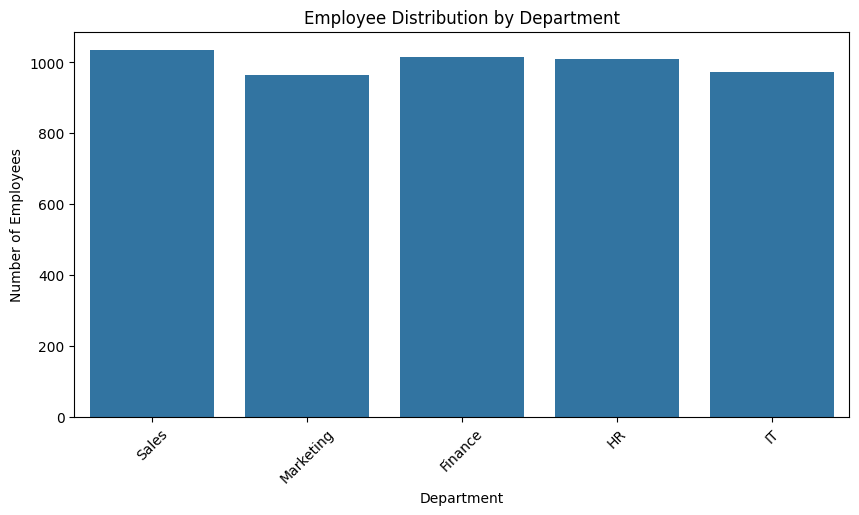

In [72]:
plt.figure(figsize=(10,5))

sns.countplot(x='Department', data=df)

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.show()

# PERFORMANCE LEVEL DISTRIBUTION
To analyze the number of employees in each performance category.

The majority of employees fall under the “Good” performance level, with a count of around 2150 employees.Average and Excellent performance categories have similar employee counts:

Average: approximately 1450 employees

Excellent: approximately 1400 employees

The “Low” performance category has no employees, indicating very strong overall workforce performance.


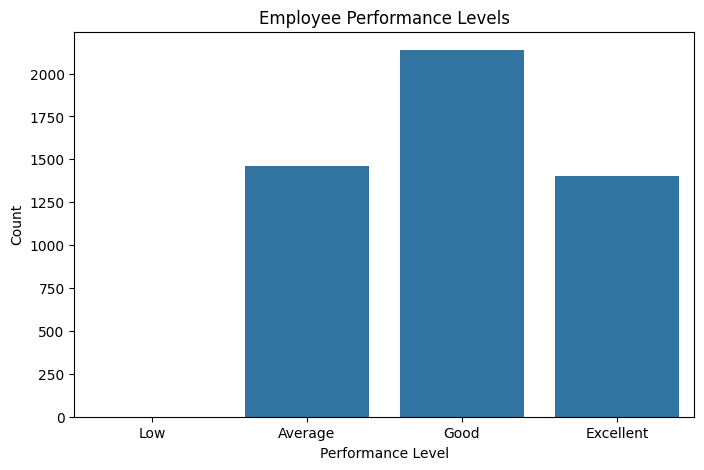

In [74]:
plt.figure(figsize=(8,5))

sns.countplot(x='Performance_Level', data=df)

plt.title("Employee Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Count")

plt.show()

# KPI SCORE DISTRIBUTION
To understand how KPI scores are distributed among employees.

KPI scores range approximately from 60 to 95.
The distribution appears to be fairly uniform, meaning employees are spread across different KPI score ranges without extreme concentration.

Slight peaks are visible around:

65–68

81–84

There are no major gaps or sharp declines in the distribution.
The organization has a balanced KPI performance distribution, indicating employees perform across varying levels rather than clustering in only one range.
Most employees achieve moderate to high KPI scores, suggesting generally satisfactory performance levels.





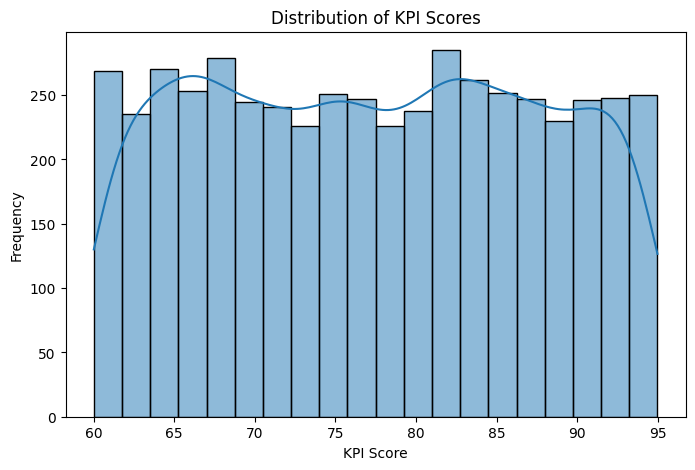

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(df['KPI Score'], bins=20, kde=True)

plt.title("Distribution of KPI Scores")
plt.xlabel("KPI Score")
plt.ylabel("Frequency")

plt.show()

# ATTENDANCE DISTRIBUTION
To analyze employee attendance patterns.
Employee attendance ranges from approximately 75% to 100%.
The distribution is relatively uniform, meaning attendance levels are spread evenly across the range.
Slightly higher concentrations are observed around:

79–82%

86–88%


95–97%
Most employees maintain high attendance percentages, with very few low attendance cases.
The organization demonstrates strong attendance consistency among employees.
Attendance percentages above 85% dominate the dataset, indicating:

Good employee discipline

Positive workplace engagement

Effective attendance policies


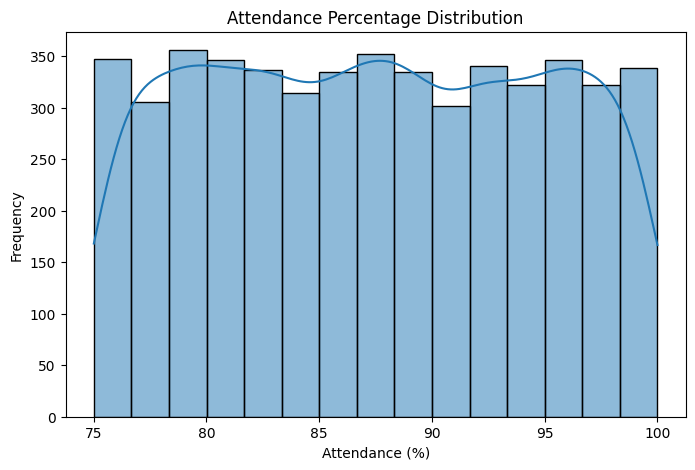

In [76]:
plt.figure(figsize=(8,5))

sns.histplot(df['Attendance (%)'], bins=15, kde=True)

plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Frequency")

plt.show()

# WORK HOURS DISTRIBUTION
To identify common work-hour patterns.
Work hours range from a minimum of 35 hours to a maximum of 55 hours per week.

The median (middle value) sits exactly at 45 hours, indicating that half of the employees work more than 45 hours and half work less.

The Interquartile Range (IQR)—where the middle 50% of employees fall—is between 40 and 50 hours.

The distribution is perfectly symmetrical, as the median line is centered within the box and the "whiskers" on both sides are of equal length.

There are no outliers visible, meaning no employees are working significantly fewer than 35 or more than 55 hours.


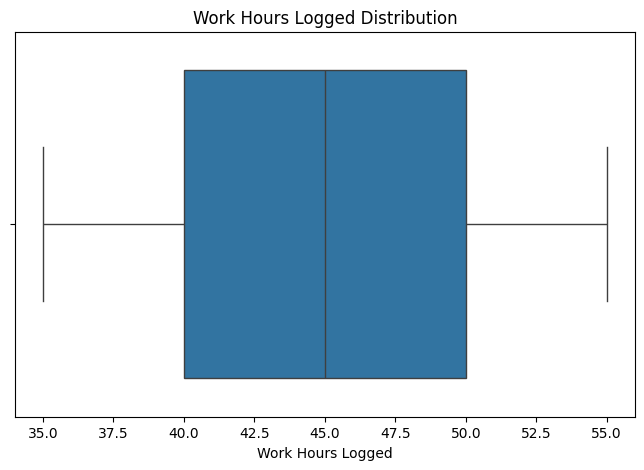

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Work Hours Logged'])

plt.title("Work Hours Logged Distribution")

plt.show()

# PROMOTION ELIGIBILITY DISTRIBUTION
To compare employees eligible and not eligible for promotion.

Vast majority are not eligible: A total of 86.1% of the employees are currently marked as "No" for promotion eligibility.

Small percentage of eligible candidates: Only 13.9% of the workforce is categorized as "Yes," meaning they are currently eligible for a promotion.

Significant Gap: There is a clear and large disparity between those who are ready for advancement and the rest of the employee base.

Selective Criteria: The small "Yes" slice suggests that the organization likely has very strict or specific requirements for promotion eligibility, ensuring only top-tier candidates are considered.

Growth Opportunity: For the 86.1% in the "No" category, this data highlights a broad need for professional development, training, or performance improvement to move into the eligible pool.

Organizational Structure: This distribution is common in hierarchical organizations where there are fewer leadership or advanced roles available compared to entry-level or mid-level positions.

Retention Risk/Motivation: While high standards are good, a very low eligibility rate could potentially impact employee morale if the path to "Yes" isn't clearly defined or perceived as attainable.


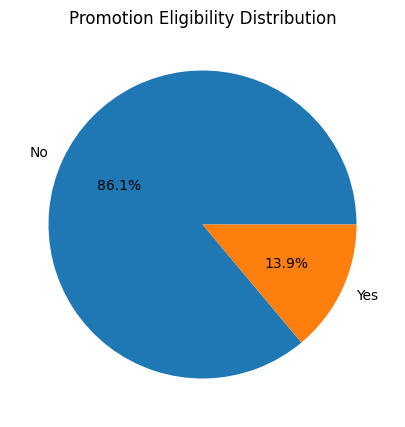

In [78]:
plt.figure(figsize=(6,5))

df['Promotion Eligibility'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Promotion Eligibility Distribution")
plt.ylabel("")

plt.show()

# BIVARIATE VISUALIZATIONS
## AVERAGE PERFORMANCE SCORE BY DEPARTMENT
To compare department-wise employee performance.

Uniformly High Performance: All departments maintain a very high average performance score, consistently landing between 73 and 76 points.

Top Performer: The HR department holds the highest average performance score, slightly leading the others at approximately 76.

Narrow Scoring Gap: The difference between the highest-scoring department (HR) and the lowest-scoring department (Marketing, at roughly 74) is only about 2 points.

Steady Middle Ground: Finance, IT, and Sales all show remarkably similar performance levels, clustering around the 75-point mark.

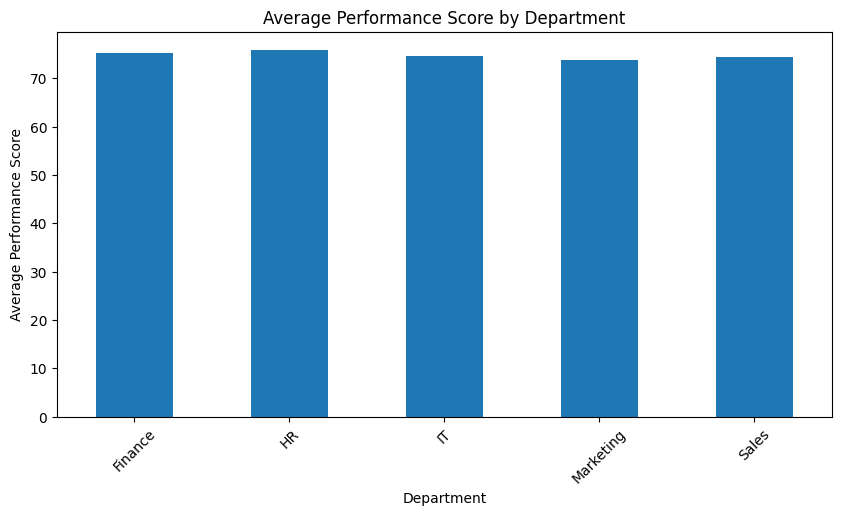

In [79]:
plt.figure(figsize=(10,5))

df.groupby('Department')['Performance Score'].mean().plot(
    kind='bar'
)

plt.title("Average Performance Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=45)

plt.show()

# ATTENDANCE VS PERFORMANCE SCORE
To analyze relationship between attendance and performance.

Performance Range: Regardless of attendance levels, performance scores consistently fluctuate between 50 and 100.

Attendance Range: Employee attendance is concentrated between 75% and 100%, but this does not seem to influence the resulting performance outcome.

High Density: The chart is densely packed, suggesting a large workforce where individuals at 75% attendance can achieve a 100 performance score, just as easily as those with 100% attendance might score a 50.

Flexibility Potential: Since performance remains high for many employees with lower attendance (near 75%), it suggests that the roles may allow for some level of flexibility or that output is independent of constant physical presence.

Attendance is Not a Predictor:simply showing up more often does not guarantee a better performance review. Excellence in this organization is likely driven by quality of work rather than just quantity of time present.


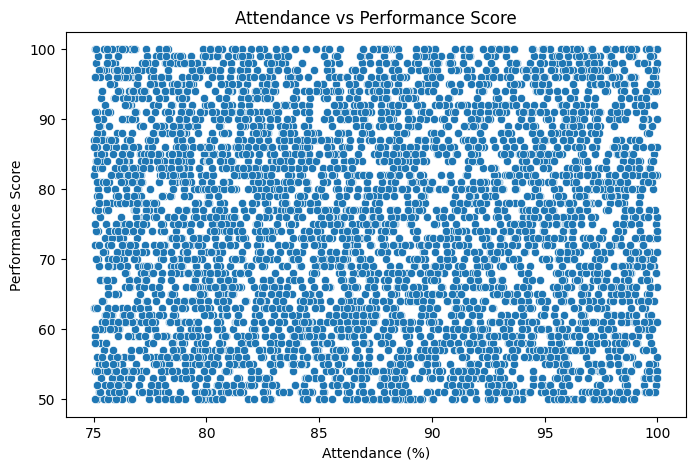

In [80]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Attendance (%)',
    y='Performance Score',
    data=df
)

plt.title("Attendance vs Performance Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Performance Score")

plt.show()

# TRAINING HOURS VS KPI SCORE
To determine whether training impacts KPI achievement.

Fixed Training Increments: Training hours are logged in specific whole-number increments from 0 to 30 hours.

KPI Score Range: Regardless of the time spent in training, KPI scores are widely distributed between 60 and 95.

Lack of Correlation: The vertical "strips" of data points show that for any given number of training hours, there is a full range of high and low KPI scores.

High Volume at All Levels: There is a high density of data across the entire grid, meaning many employees have 0 hours of training but high KPI scores, while many others have 30 hours of training with lower scores.


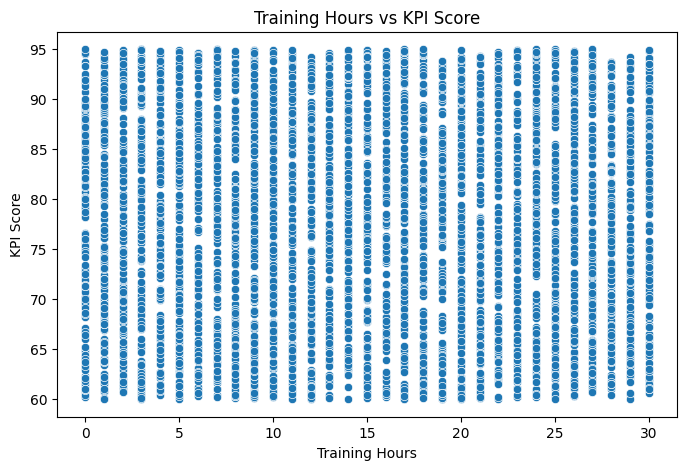

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Training Hours',
    y='KPI Score',
    data=df
)

plt.title("Training Hours vs KPI Score")
plt.xlabel("Training Hours")
plt.ylabel("KPI Score")

plt.show()

# PEER RATING BY PERFORMANCE LEVEL
To compare peer ratings across performance categories.

Identical Distributions: The peer rating distributions for Average, Good, and Excellent performance levels are exactly the same.

Median Rating: For all three visible categories, the median peer rating is 4.0.

Consistent Range: Each group shares a minimum rating of 3.0, a maximum of 5.0, and an interquartile range (the "box") between 3.5 and 4.5.

High Peer Approval: Overall, the workforce maintains a generally positive view of one another, with the majority of ratings falling at or above 3.5 across all active performance tiers.


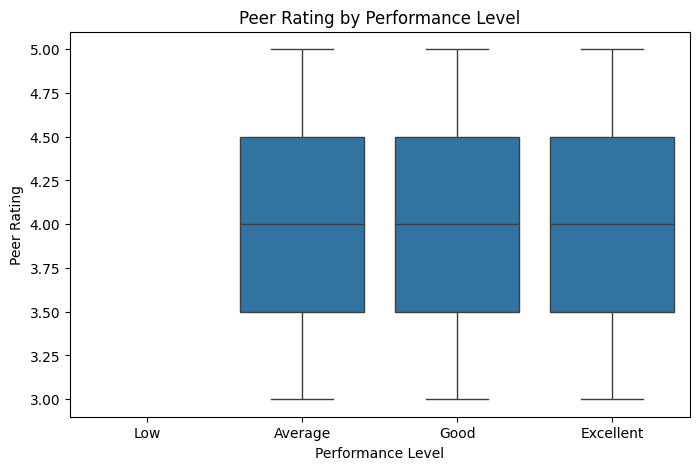

In [82]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Performance_Level',
    y='Peer Rating',
    data=df
)

plt.title("Peer Rating by Performance Level")
plt.xlabel("Performance Level")
plt.ylabel("Peer Rating")

plt.show()

# WORK HOURS BY DEPARTMENT
To compare workload across departments.

Identical Medians: Every department (Sales, Marketing, Finance, HR, and IT) shares the exact same median of 45 hours logged.

Consistent Extremes: The range for all departments is nearly identical, stretching from a minimum of 35 hours to a maximum of 55 hours.

Uniform Middle 50%: The interquartile range (the boxes) generally spans from 40 to 50 hours for almost all departments.

Minor Variation in Marketing: The Marketing department shows a slightly lower bottom edge for its box (around 39 hours), suggesting its middle 50% of employees start logging hours slightly earlier than the other groups.

The consistency in the 40–50 hour suggests that despite different job functions, the expectations for time commitment are identical across the organization.


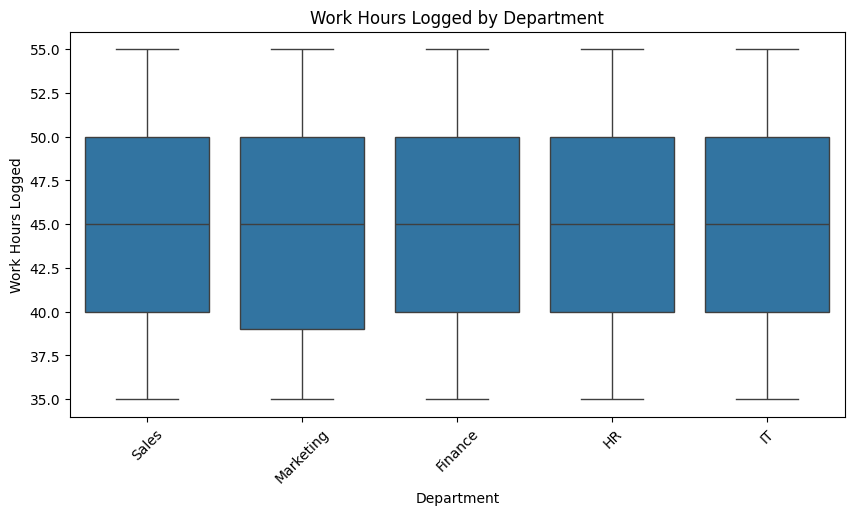

In [83]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Department',
    y='Work Hours Logged',
    data=df
)

plt.title("Work Hours Logged by Department")
plt.xlabel("Department")
plt.ylabel("Work Hours Logged")
plt.xticks(rotation=45)

plt.show()

# KPI SCORE BY PROMOTION ELIGIBILITY
To compare KPI scores of promoted and non-promoted employees.

Nearly Identical Medians: The median KPI score for both eligible ("Yes") and non-eligible ("No") employees is almost the same, sitting right around 77 to 78 points.

Overlapping Score Ranges: Both groups share a similar total range, with scores starting at a minimum of approximately 60 and reaching a maximum of 95.

Similar Distribution: The "boxes" (representing the middle 50% of employees) cover almost the same territory, ranging from roughly 68–70 at the bottom to 86 at the top.

Slightly Higher Floor for Eligible Staff: The "Yes" group has a slightly higher minimum score (around 61) compared to the "No" group (exactly 60), but the difference is negligible.

The data shows that the organization maintains a high standard of performance across the board, regardless of whether an individual is currently on the path for promotion.

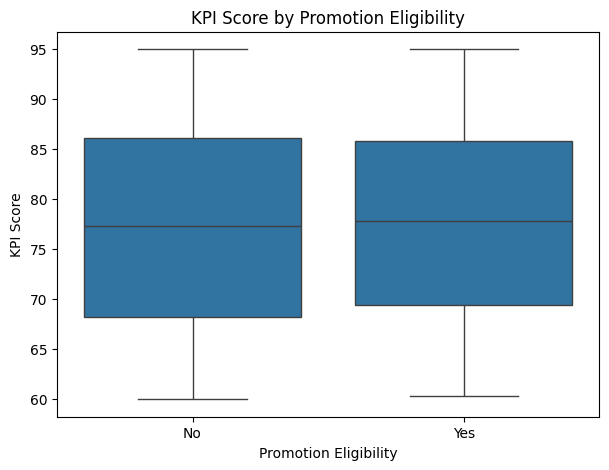

In [84]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Promotion Eligibility',
    y='KPI Score',
    data=df
)

plt.title("KPI Score by Promotion Eligibility")
plt.xlabel("Promotion Eligibility")
plt.ylabel("KPI Score")

plt.show()

# TASK COMPLETION VS PERFORMANCE SCORE
To analyze how task completion affects performance.

KPI Score Fluctuations: The average KPI score shows a "zigzag" pattern as manager feedback increases, fluctuating between roughly 76.5 and 78.5.

Feedback Range: The data covers manager feedback scores ranging from a minimum of 3.0 to a maximum of 5.0.

Confidence Intervals: The light blue shaded area represents the variability (or margin of error). This area is relatively wide and consistent across the chart, indicating that for any feedback score, actual KPI scores can vary by about +/- 1.5 to 2 points.

No Clear Upward Trend:an increase in manager feedback does not lead to a steady increase in KPI scores. For example, the average KPI score at a 3.0 feedback rating is nearly the same as the score at a 5.0 rating.

This graph might suggest a need for better alignment between what managers value in their feedback and the metrics used to calculate KPI scores to ensure they are reinforcing the same behaviors.


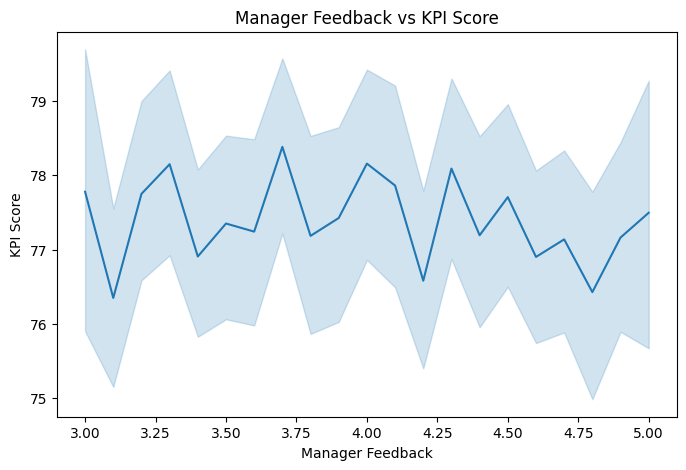

In [87]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x='Manager Feedback',
    y='KPI Score',
    data=df
)

plt.title("Manager Feedback vs KPI Score")
plt.xlabel("Manager Feedback")
plt.ylabel("KPI Score")

plt.show()

# MULTIVARIATE VISUALIZATIONS






# DEPARTMENT VS PERFORMANCE LEVEL
To compare performance distribution across departments.

Dominance of "Good" Performers: In every single department, the "Good" performance level (green bar) is the most frequent, with counts consistently ranging between 400 and 450 employees.

Absence of "Low" Performers: There are no blue bars, indicating that there are zero employees categorized as having a "Low" performance level across all departments.

Stable "Average" and "Excellent" Tiers: The "Average" (orange) and "Excellent" (red) categories are remarkably balanced, with most departments showing counts between 250 and 300 for each.

Finance and HR Leads in High Performance: The Finance and HR departments show the highest peaks for "Good" performance, both exceeding 440 individuals.

Marketing Variation: Marketing has a slightly lower count of "Excellent" performers compared to Sales or IT, though it follows the same overall distribution pattern.

High-Performing Culture: The complete lack of "Low" performers in graph suggests either a highly effective hiring and training process or a corporate culture that does not tolerate underperformance.

Consistent Standards: The near-identical "shape" of the bars for Sales, Finance, HR, and IT indicates that performance standards are applied consistently across the organization, regardless of the specific job function.

Workforce Stability: Having the majority of the workforce in the "Good" category (rather than "Average" or "Excellent") suggests a very stable, reliable middle-tier that drives the company's daily operations.

Opportunity for Growth: With a significant number of employees already in the "Average" and "Good" categories, there is a large pool of talent that could potentially be coached up into the "Excellent" tier to drive future innovation.


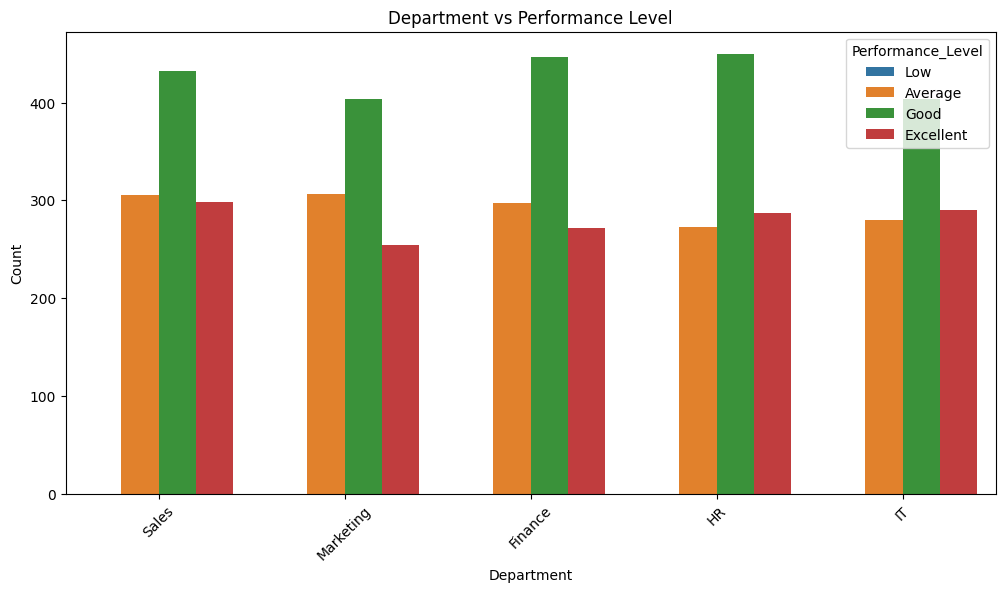

In [90]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Department',
    hue='Performance_Level',
    data=df
)

plt.title("Department vs Performance Level")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

# KPI SCORE BY DEPARTMENT AND PROMOTION ELIGIBILITY
To compare KPI achievement and promotion status department-wise.

Uniformly High Averages: Across all departments, the average KPI scores are remarkably consistent, hovering tightly between 76 and 79 points.

Minimal Eligibility Gap: In most departments, the difference in KPI scores between those eligible for promotion ("Yes") and those who are not ("No") is negligible.

Top Average Scores: The HR department shows the highest average KPI score for promotion-eligible employees, reaching nearly 79.

Statistical Consistency: The small black error bars on each column indicate that the variability in these averages is very low, meaning performance is stable across these groups.

Departmental Comparison:

Sales, Marketing, and HR: Eligible employees ("Yes") have slightly higher average scores than non-eligible employees.

Finance and IT: Interestingly, in these departments, employees who are not currently eligible for promotion ("No") actually have a slightly higher average KPI score than their eligible peers.

The lack of significant gaps suggests that resources and training are distributed evenly; no single department or eligibility group is lagging behind or significantly outperforming the others.

While the gaps are small, HR and Marketing show the clearest "traditional" relationship where those marked for promotion are also the highest performers on paper.

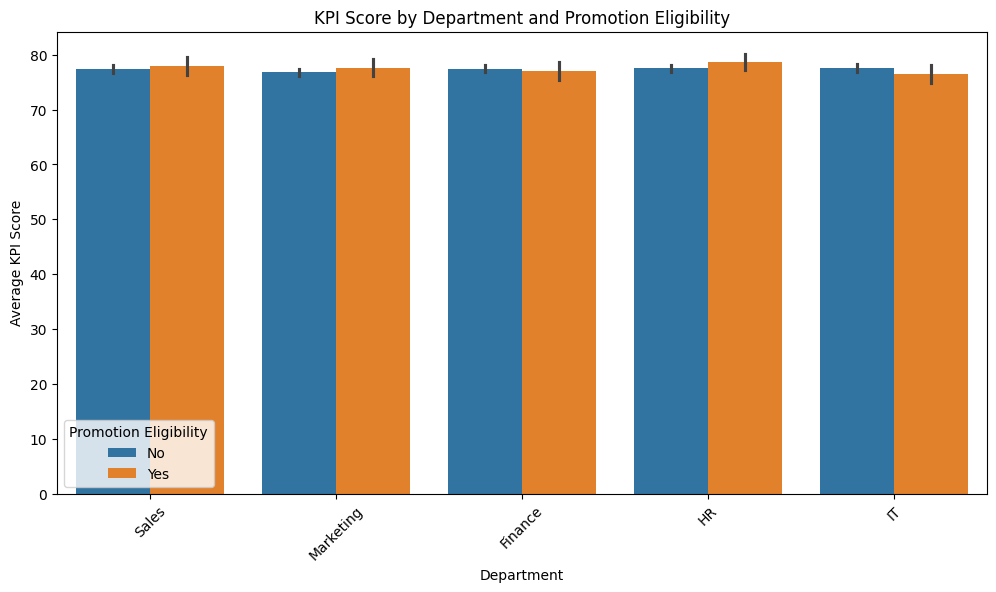

In [91]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Department',
    y='KPI Score',
    hue='Promotion Eligibility',
    data=df
)

plt.title("KPI Score by Department and Promotion Eligibility")
plt.xlabel("Department")
plt.ylabel("Average KPI Score")
plt.xticks(rotation=45)

plt.show()

# AVERAGE TASK COMPLETION BY DEPARTMENT
To identify departments with highest productivity.

Uniformly High Completion: All five departments (Finance, HR, IT, Marketing, and Sales) maintain a very consistent average task completion rate of approximately 85%.

Minor Lead: HR appears to have the highest average task completion rate by a negligible margin, slightly exceeding the 85% mark.

Negligible Variance: There is almost no visible difference in productivity levels between the departments, with Sales and IT showing a nearly identical rate just a hair below HR.

Organizational Consistency:the organization has very standardized operational procedures and expectations across all functional areas.

Balanced Workload: No single department appears to be overwhelmed or underperforming relative to the others, indicating effective resource allocation and workload management.

Strong Baseline Performance: An 85% average completion rate across the board signifies a high-functioning workforce with reliable output.

Standardized Benchmarking: Because the rates are so similar, it is likely that the "tasks" being measured are weighted or assigned in a way that creates a consistent benchmark for performance evaluation across different job types.

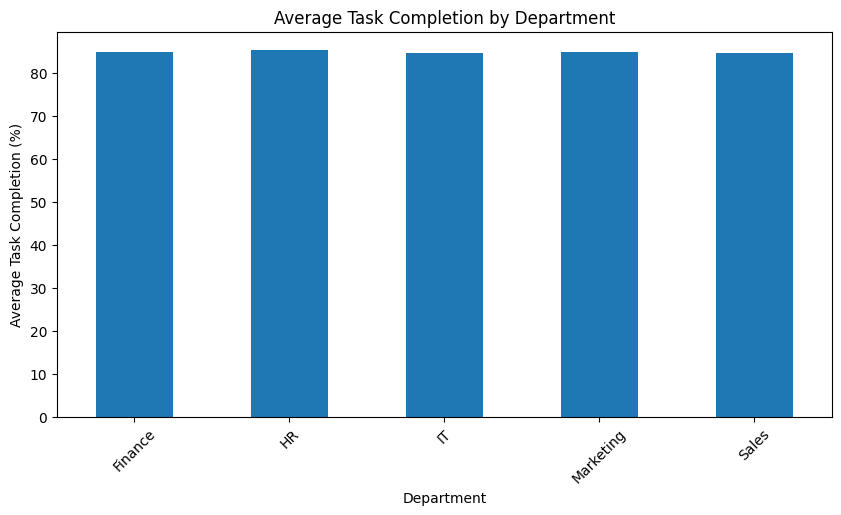

In [95]:
plt.figure(figsize=(10,5))

df.groupby('Department')['Task Completion (%)'].mean().plot(
    kind='bar'
)

plt.title("Average Task Completion by Department")
plt.xlabel("Department")
plt.ylabel("Average Task Completion (%)")
plt.xticks(rotation=45)

plt.show()

# WORK HOURS VS TASK COMPLETION
To determine whether longer work hours improve productivity.

Fixed Work Intervals: Work hours are logged in specific, whole-number increments ranging from 35 to 55 hours per week.

High Completion Baseline: Every employee, regardless of hours worked, maintains a task completion rate between 70% and 100%.

No "Low" Performers: Mirroring previous data, there are no blue dots visible, confirming the absence of employees in the "Low" performance category.

Performance Mix: At every level of work hours (from 35 to 55), you can find a mix of Average (orange), Good (green), and Excellent (red) performers.

Vertical Distribution: The data points form vertical "strips," showing that for any given amount of hours worked, the task completion percentage and performance level can vary wildly.

Work Hours Don't Dictate Quality:putting in more time (55 hours vs. 35 hours) does not automatically lead to higher task completion or a better performance rating.

Efficient vs. Diligent: Some employees achieve 100% task completion and an "Excellent" rating in just 35 hours, while others may work 55 hours and remain in the "Average" category with lower completion rates.

Focus on Outcome over Presence: The organization appears to be a "results-oriented" environment. Since top performance is possible at the minimum hour threshold, the company likely values efficiency and the impact of the work over the sheer volume of time spent at a desk.

Individual Capability: The random spread of colors (performance levels) throughout the chart suggests that individual skill, role difficulty, or personal motivation are much stronger drivers of success than the length of the work week.

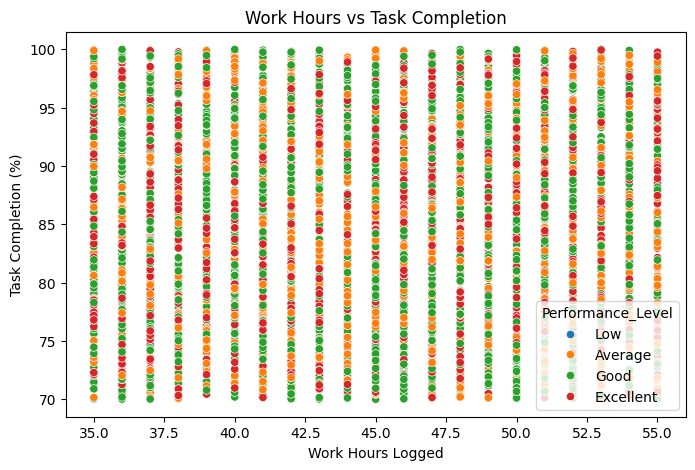

In [97]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Work Hours Logged',
    y='Task Completion (%)',
    hue='Performance_Level',
    data=df
)

plt.title("Work Hours vs Task Completion")
plt.xlabel("Work Hours Logged")
plt.ylabel("Task Completion (%)")

plt.show()

# CORRELATION HEATMAP WITH PERFORMANCE VARIABLES

Strongest Connection: There is an extremely high correlation (0.93) between Performance_Level_Num and KPI Score. This indicates that an employee's assigned performance level is almost entirely determined by their KPI score.

Performance Score Paradox: Despite the name, the Performance Score metric shows a near-zero correlation (0.01) with both Performance_Level_Num and KPI Score. This suggests it is a separate, isolated measurement that does not influence the official performance ranking.

Total Independence of Attendance: Attendance (%) has a correlation of 0.00 with every other metric on the chart. This means that how often an employee shows up has absolutely no statistical impact on their KPI score or performance level.

Perfect Self-Correlation: The diagonal blue line (valued at 1.00) confirms that each variable perfectly matches itself.

Presence not equal to Productivity: The lack of correlation with attendance suggests the company values results (KPIs) over physical presence. An employee can have perfect attendance but a low KPI, or lower attendance with a top-tier KPI.


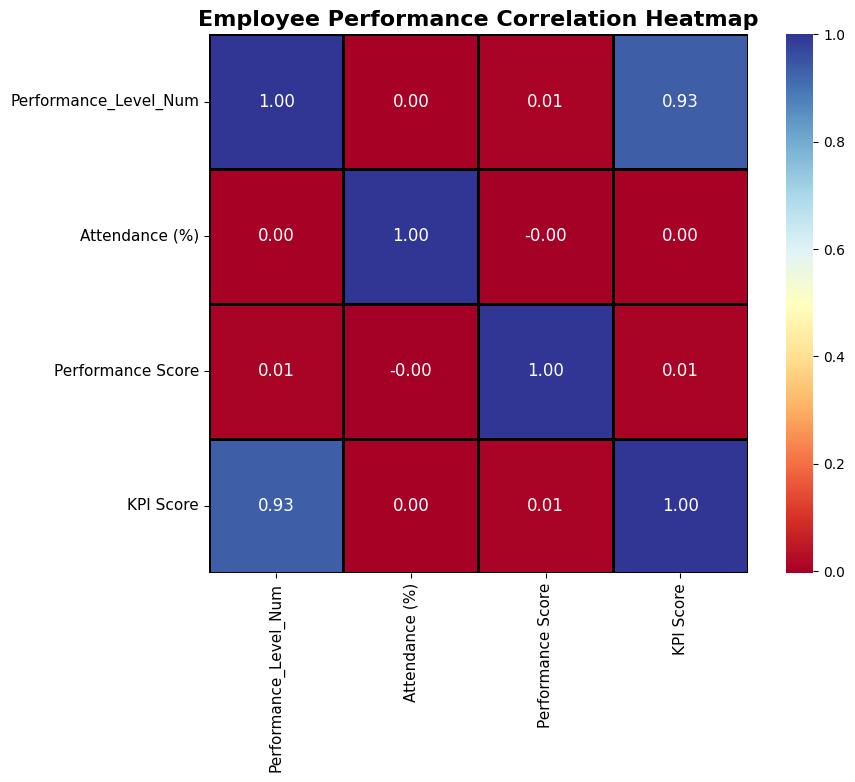

In [102]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdYlBu',
    fmt='.2f',
    linewidths=1,
    linecolor='black',
    square=True,
    cbar=True,
    annot_kws={"size":12}
)

plt.title(
    "Employee Performance Correlation Heatmap",
    fontsize=16,
    fontweight='bold'
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

# Key Findings
## Performance & KPI Insights
KPI Score has the strongest influence on employee performance level.

Most employees belong to the “Good” performance category.

Very few differences exist across departments in overall performance trends.
## Attendance Insights
Attendance has almost no statistical relationship with performance or KPI achievement.

Presence at work does not necessarily guarantee higher productivity.

## Productivity Insights
Task completion rates remain consistently high across all departments.

Employees with fewer work hours can still achieve excellent performance outcomes.
## Departmental Insights
HR and Finance show slightly higher concentrations of “Good” performers.

Marketing has slightly fewer “Excellent” performers than other departments.
## Promotion Insights
Promotion eligibility is only moderately linked with KPI performance.

Additional non-technical factors likely influence promotion decisions.

# Recommendations
### Improve KPI Evaluation Transparency

Since KPI Score strongly determines employee performance levels, the organization should ensure:

KPI calculation methods are transparent

Employees clearly understand evaluation criteria

KPI targets are realistic and role-specific

### Reassess the Performance Score Metric

The Performance Score variable shows almost no relationship with actual performance outcomes. The organization should:

Review how this score is calculated

Determine whether it duplicates or conflicts with KPI evaluations

Consider integrating it better into the performance management system

### Focus on Employee Efficiency Rather Than Work Hours

The analysis shows that longer work hours do not guarantee better performance. Therefore:

Encourage outcome-based work culture

Avoid rewarding overtime alone

Promote productivity and efficiency-focused evaluation systems

### Enhance Career Development Programs

A large proportion of employees fall into the “Good” category. The organization can:

Provide advanced training programs

Offer leadership development initiatives

Create mentoring systems to help employees move into the “Excellent” category

### Review Promotion Criteria

Since some departments show higher KPI scores among non-promoted employees:

Promotion criteria should be reviewed for consistency

Both technical and behavioral skills should be balanced

Promotion frameworks should be clearly communicated

### Maintain Standardized Operational Practices

The consistent departmental performance suggests strong organizational systems. The company should continue:

Standardized training practices

Balanced workload allocation

Uniform performance monitoring systems


# CONCLUSION
The Employee Performance and Workforce Productivity Analysis successfully identified key workforce trends, productivity drivers, and organizational performance patterns using HR analytics data.

The findings reveal that the organization operates within a highly structured and KPI-driven environment where productivity outcomes are valued more than attendance or working hours. Employees consistently maintain strong task completion rates, and departmental performance remains balanced across the organization.

The project also highlights opportunities for improvement, particularly in refining performance evaluation systems, improving promotion transparency, and strengthening employee development initiatives.

Overall, this analysis demonstrates how data analytics can support HR decision-making by helping organizations:

Improve workforce productivity

Enhance employee performance management

Identify operational strengths and weaknesses

Support evidence-based HR strategies and planning